# RDA GO

> Redundancy analysis genomic offset

The genomic offset based on Redundancy analysis as done in @Capblancq_2021. 

TODO!

In [ ]:
#| default_exp RDA

In [ ]:
#| hide
from fastcore.utils import *
from nbdev.showdoc import *
import numpy as np
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [ ]:
#| export
class RDA:
    "Redundancy analysis genomic offset statistic."
    def __init__(self, K: int):
        self._reg = LinearRegression(copy_X=True, fit_intercept=True)
        self._pca = PCA(n_components=K)
    def __str__(self):
        return "Redundancy analysis model"
    __repr__ = __str__

In order to use the model we have first to initialize it with a maximum number of canonical axes `K`. 

In [ ]:
K = 2
model = RDA(K)

Then, we have to fit the model ...

In [ ]:
#|export
@patch
def fit(self:RDA,
        Y: np.ndarray, # Allele frequency matrix (nxL)
        X: np.ndarray): # Environmental matrix (nxP)
    "Fits the RDA model. "
    n1, L = Y.shape
    n2, P = X.shape
    if n1 != n2: 
        raise ValueError("Dimensions of array don't match")
    self._reg.fit(X, Y)
    self._pca.fit(self._reg.predict(X))

The `fit()` method expects as input an allele matrix $\mathbf Y$ and an environmental matrix $\mathbf X$ with as many rows as individuals. For now, let us simulate them under the ¿generative model?: 

In [ ]:
N, L, P = 100, 10_000, 30
rng = np.random.default_rng(1000)
X = rng.normal(loc=0.0, scale=1.0, size=(N, P))
p = rng.uniform(low=0, high=1, size = (1, L))
B = rng.normal(loc=0.0, scale=0.1, size = (P, L))
Y = X@B + np.ones((N, 1))@p
Y = Y.clip(0, 1)
assert X.shape == (N, P)
assert Y.shape == (N, L)

In [ ]:
indices = rng.permutation(N)
training_idx, test_idx = indices[:60], indices[60:]
Xtrain, Xpredict = X[training_idx,:], X[test_idx,:]
Ytrain, Ypredict = Y[training_idx,:], Y[test_idx,:]
model.fit(Ytrain, Xtrain)

Now, we can make predictions: 

In [ ]:
#| export 
@patch
def predict(self:RDA,
        X: np.ndarray # Environmental matrix (nxP)
           )-> np.ndarray: # Predicted allele frequencies
    "Predicts the allele frequencies for a given environmental matrix. "    
    return self._pca.transform(self._reg.predict(X))

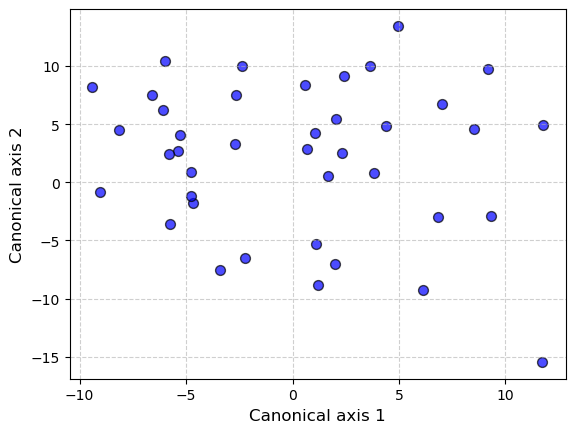

In [ ]:
proj = model.predict(Xpredict)
fig, ax = plt.subplots()
scatter = ax.scatter(proj[:, 0], proj[:, 1], c='blue', edgecolor='k', alpha=0.7, s=50)
ax.set_xlabel('Canonical axis 1', fontsize=12)
ax.set_ylabel('Canonical axis 2', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
plt.show()


Finally, we can predict the genomic offset under two different environments: 

In [ ]:
#| export 
@patch
def genomic_offset(self:RDA,
        X: np.ndarray, # Environmental matrix (nxP)
        Xstar: np.ndarray, # Altered environmental matrix (nxP)
           )-> np.ndarray: # A vector of genomic offsets (n)
    "Predicts the allele frequencies for a given environmental matrix. " 
    if X.shape != Xstar.shape: 
        raise ValueError("Dimensions of array don't match")
    offset = np.zeros(X.shape[0])
    diff = self.predict(X) - self.predict(Xstar)
    weights = self._pca.explained_variance_ / np.sum(self._pca.explained_variance_ )
    L = model._reg.coef_.shape[0]
    for distance, w in zip(diff.T, weights):
        offset += distance**2*w/L
    return offset
    

As expected, the genomic offset is zero if both environmental matrixes are identical: 

In [ ]:
model.genomic_offset(Xpredict, Xpredict)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0.])

In [ ]:
offset = model.genomic_offset(Xpredict, Xpredict+rng.normal(size=Xpredict.shape))
offset

array([5.39852360e-03, 3.31891379e-03, 2.33085794e-03, 8.17232971e-04,
       1.63686724e-03, 1.24831279e-02, 4.69995253e-04, 3.98106679e-03,
       2.29109370e-03, 5.52494418e-03, 1.29675344e-03, 5.26726624e-03,
       5.92548913e-03, 3.52826246e-03, 8.30134567e-03, 6.48115957e-04,
       2.79638212e-03, 3.47318628e-03, 4.43484174e-04, 1.07680185e-02,
       1.32369701e-02, 2.30746454e-03, 3.10176064e-03, 3.11801420e-05,
       2.59216661e-03, 1.76360436e-04, 5.86381326e-04, 1.07921045e-04,
       2.89396423e-03, 1.15138670e-02, 3.56155393e-03, 1.10281948e-02,
       4.12672987e-03, 6.44580529e-03, 1.35210643e-03, 8.99304595e-03,
       1.71281696e-02, 6.34884722e-03, 4.22020295e-03, 3.03523790e-04])

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()